In [51]:
%cd ..
from helpers.helpersGeneration import *
from helpers.helpersSimulation import *
from helpers.helpersTracking import *
from helpers.helpersStatistics import *
from helpers.helpersAssignment import *

c:\Users\armel\OneDrive - epfl.ch\MA2\SMLM


In [52]:
D_list = [
    (0.10, 0.30),
    (0.50, 0.10),
    (1.50, 0.15),
    (3.50, 0.10),
    (4.00, 0.15),
    (5.00, 0.20),
]

simulation_config = {
    "nparticles": 15,
    "nframes": 50,
    "nposframe": 5,
    "D_list": D_list,
    "dt": 1.0,
    "anisotropy_ratio_range": (1.0, 1.0),
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": 700, # nphotons
    "intensity_std": 300,
}

image_config = {
    "particle_intensity": [700, 300],
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

sim = Simulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=42,
).run()

frames = sim.frames
trajectories_HR = sim.trajectories_HR # high-resolution trajectories with size nframes x nposframe
trajectories_GT = sim.trajectories_GT # Ground-Truth, low-resolution trajectories with size nframes
trajectories_FR = sim.trajectories_FR # low-resolution trajectories with size nframes, with diffusion data computed from GT
video_aniso = sim.video

In [53]:
sim.animate(interval=100, cmap="gray")

In [54]:
# define custom cost function for peak-to-peak assignment: separate weights between distance, intensity and sigma
peak2peak_cost = PeakToPeak(
    terms={
        "distance": DistanceTerm(weight=0.5, norm=image_config["output_size"]/10),
        "intensity": IntensityTerm(weight=0.5, norm=image_config["particle_intensity"][0]+image_config["particle_intensity"][1]),
    }
)

# define custom cost function for trajectory-to-trajectory assignment: fully weighted on distance between trajectories
traj_cost = TrajToTraj(
    terms={
        "position": MeanPositionDistanceTerm(weight=0.8, norm=1.0),
        "length": LengthDifferenceTerm(weight=0.1, norm=10),
        "start_frame": StartFrameDifferenceTerm(weight=0.1, norm=5),
    }
)

In [ ]:
detection_results = sim.track(
    mode="detection",
    detection_threshold=None,
    max_distance=10,
    min_length=5,
    r_squared_threshold=0.5,
    algo_peak2peak="hungarian",
    cost_func_peak2peak=peak2peak_cost,
    algo_traj2traj="hungarian",
    cost_func_traj2traj=traj_cost,
    verbose_loc=False,
    visualization_loc=False,
    verbose_assignment=False,
)

In [57]:
localization_results = sim.track(
    mode="localization",
    detection_threshold=400,
    max_distance=5,
    min_length=5,
    cost_func_peak2peak=peak2peak_cost,
    cost_func_traj2traj=traj_cost
)

[Frame 0] Fitted center for peak at (90, 88): (89.43, 87.71), amplitude 668.99, sigma 1.38
[Frame 0] Fitted center for peak at (57, 94): (56.71, 93.87), amplitude 674.00, sigma 1.42
[Frame 0] Fitted center for peak at (57, 16): (57.34, 16.31), amplitude 643.24, sigma 1.47
[Frame 0] Fitted center for peak at (40, 73): (39.28, 73.64), amplitude 602.35, sigma 2.00
[Frame 0] Fitted center for peak at (40, 18): (39.80, 18.63), amplitude 625.62, sigma 1.71
[Frame 0] Fitted center for peak at (102, 26): (101.53, 26.24), amplitude 504.95, sigma 1.59
[Frame 0] Fitted center for peak at (38, 74): (38.96, 73.37), amplitude 660.51, sigma 2.03
[Frame 0] Fitted center for peak at (53, 37): (52.69, 36.73), amplitude 417.38, sigma 1.29
[Frame 0] Fitted center for peak at (68, 48): (68.71, 47.63), amplitude 627.38, sigma 1.86
[Frame 0] Fitted center for peak at (90, 26): (90.50, 25.70), amplitude 481.55, sigma 1.54
[Frame 0] Fitted center for peak at (23, 41): (22.65, 41.25), amplitude 530.70, sigma 2.

In [58]:
trajectories_detection = detection_results[0]
trajectories_localization = localization_results[0]

### MSD Evaluation

In [59]:
MSD_GT = calculateMSDtrajectories(trajectories_GT)
MSD_FR = calculateMSDtrajectories(trajectories_FR)
MSD_detection = calculateMSDtrajectories(trajectories_detection)
MSD_localization = calculateMSDtrajectories(trajectories_localization)

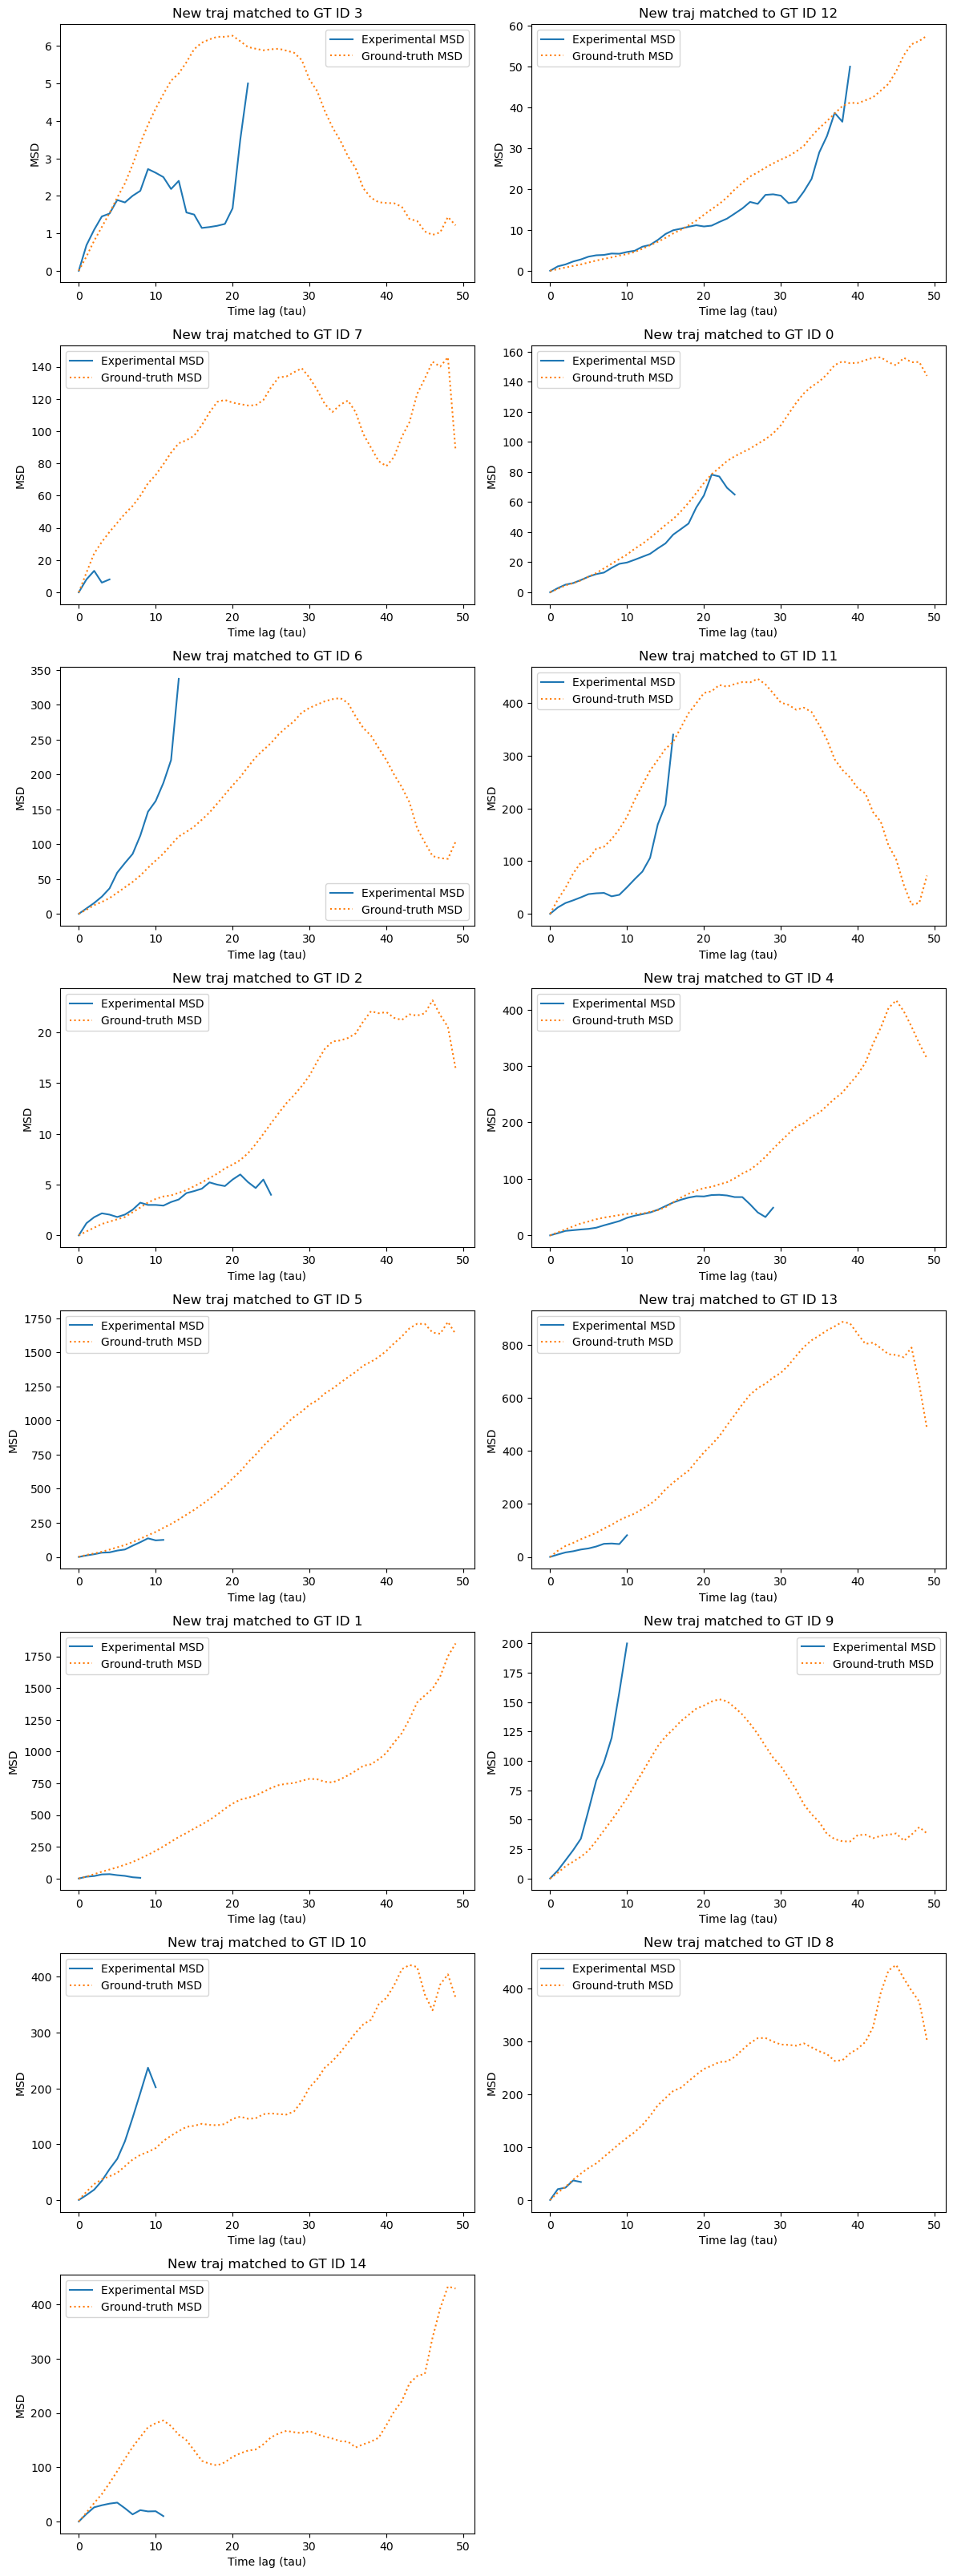

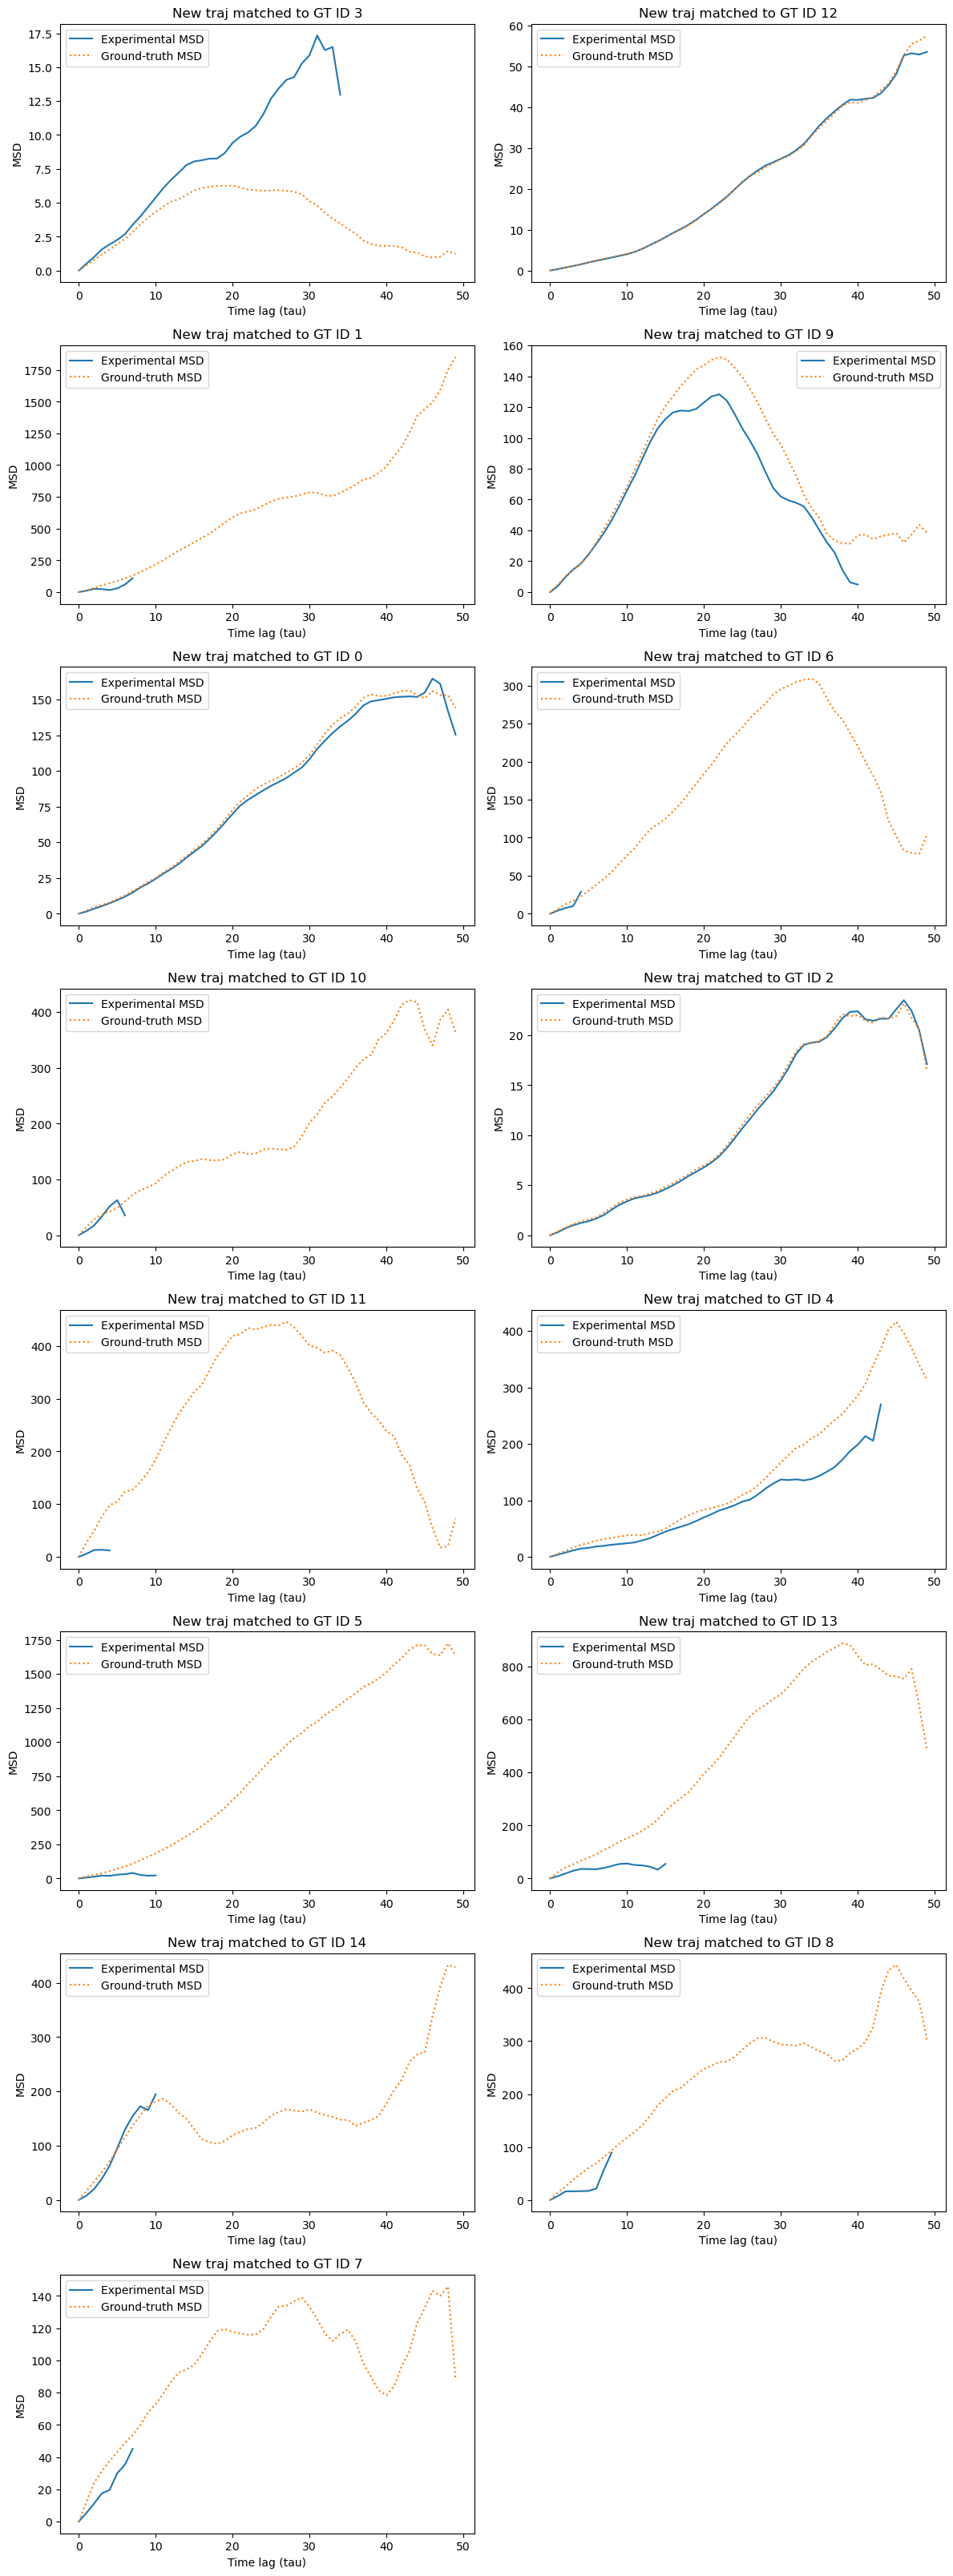

In [60]:
plotMSDvsGT(trajectories_detection, trajectories_GT)
plotMSDvsGT(trajectories_localization, trajectories_GT)

### D Evaluation

In [61]:
D_results_FR = estimateDfromTrajectories(trajectories_FR)
D_results_detection = estimateDfromTrajectories(trajectories_detection)
D_results_localization = estimateDfromTrajectories(trajectories_localization)

In [62]:
# results.append({
#             "id": traj.id,
#             "D1": D1,
#             "D2": D2,
#             "theta": theta,
#             "anisotropy": D2 / D1 if np.isfinite(D1) and D1 > 0 else np.nan,
#             "D_tensor": D_tensor,
#         })

In [63]:
traj_list = [trajectories_GT, trajectories_FR, trajectories_detection, trajectories_localization]
labels = ["GT", "FR", "Detection", "Localization"]

In [64]:
def plotDcomparison(trajectories_list, labels):
    D1_list = []
    D2_list = []
    for trajs in trajectories_list:
        D1, D2, _ = get_traj_params(trajs)
        D1_list.append(D1)
        D2_list.append(D2)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.boxplot(D1_list, labels=labels)
    plt.title("D1 comparison")
    plt.ylabel("D1 (µm²/s)")
    
    plt.subplot(1, 2, 2)
    plt.boxplot(D2_list, labels=labels)
    plt.title("D2 comparison")
    plt.ylabel("D2 (µm²/s)")
    
    plt.tight_layout()
    plt.show()

C:\Users\armel\AppData\Local\Temp\ipykernel_41840\386189727.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(D1_list, labels=labels)
C:\Users\armel\AppData\Local\Temp\ipykernel_41840\386189727.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(D2_list, labels=labels)


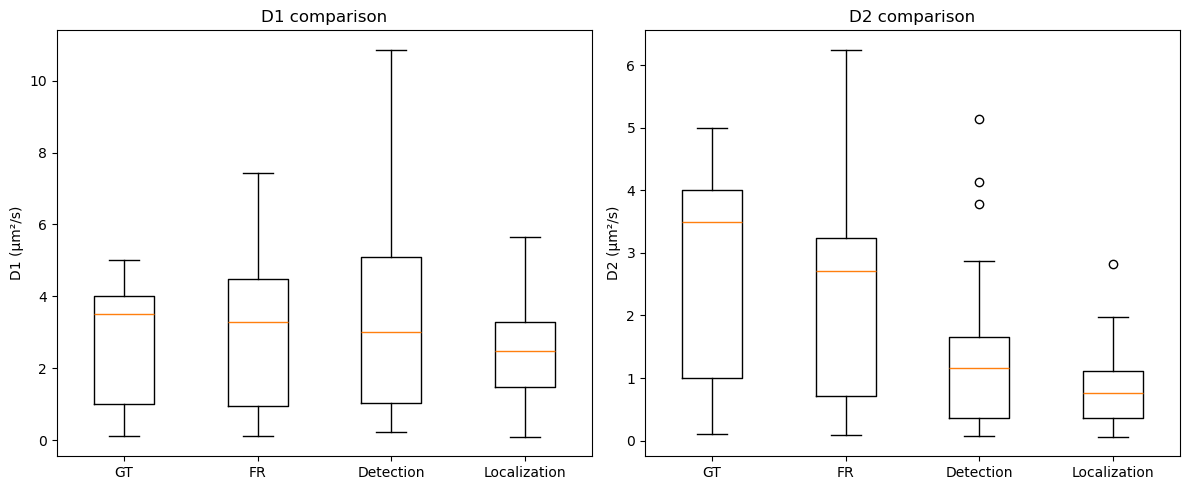

In [65]:
plotDcomparison(traj_list, labels)

In [66]:
print(trajectories_GT[3].MSD)

[0.         0.38099612 0.80100031 1.16904542 1.5440043  1.95212438
 2.33181918 2.83161283 3.40145646 3.90090087 4.33319636 4.71475934
 5.07254988 5.26697108 5.56586045 5.9147916  6.08874911 6.17666243
 6.24533784 6.24464937 6.27351267 6.1269152  5.97085351 5.92655983
 5.88487703 5.91167467 5.92641795 5.87532666 5.81942968 5.62251756
 5.10254714 4.79741494 4.26052042 3.82544183 3.47895829 3.05562789
 2.7346956  2.20102864 1.94732853 1.8282977  1.80984988 1.80176902
 1.71094479 1.38178059 1.32750542 1.04803956 0.95791241 1.02422622
 1.43652539 1.21195662]


In [67]:
def plotMSD_multi(trajectories_lists, labels):
    """
    Plot superimposed MSD curves for multiple trajectory lists.
    
    Parameters
    ----------
    trajectories_lists : list of lists
        A list where each element is a list of trajectories.
        Each trajectory must have:
            - traj.id : unique identifier (int or similar)
            - traj.MSD : array-like or None
    labels : list of str
        Labels corresponding to each trajectories list.
    
    Behavior
    --------
    - For each trajectory ID that appears in ANY list,
      plot all available MSD curves on the same subplot.
    - One subplot per trajectory ID.
    - Only plot MSD curves that exist and are non-empty.
    """

    # --- Build mapping: list_index -> {id -> trajectory} ---
    maps = []
    for trajs in trajectories_lists:
        maps.append({traj.id: traj for traj in trajs if traj.id is not None})

    # --- Collect all unique IDs across all lists ---
    all_ids = set()
    for m in maps:
        all_ids |= set(m.keys())

    if len(all_ids) == 0:
        print("No trajectories with valid IDs found.")
        return

    all_ids = sorted(all_ids)

    # --- Prepare figure layout ---
    n = len(all_ids)
    ncols = 2
    nrows = math.ceil(n / ncols)

    plt.figure(figsize=(12, 4 * nrows))

    # --- Loop over each trajectory ID ---
    for i, tid in enumerate(all_ids):
        plt.subplot(nrows, ncols, i + 1)
        plt.title(f"Trajectory ID {tid}")

        plotted_any = False

        # Loop over each list and label
        for traj_list_idx, (m, label) in enumerate(zip(maps, labels)):
            if tid in m:
                MSD = m[tid].MSD
                if MSD is not None and len(MSD) > 0:
                    plt.plot(MSD, label=label)
                    plotted_any = True

        if not plotted_any:
            plt.text(0.5, 0.5, "No MSD available", ha="center", va="center")

        plt.xlabel("Time lag (tau)")
        plt.ylabel("MSD")
        plt.legend()

    plt.tight_layout()
    plt.show()


In [68]:
traj_list3 = [ trajectories_FR, trajectories_detection, trajectories_localization]
labels = ["FR", "Detection", "Localization"]

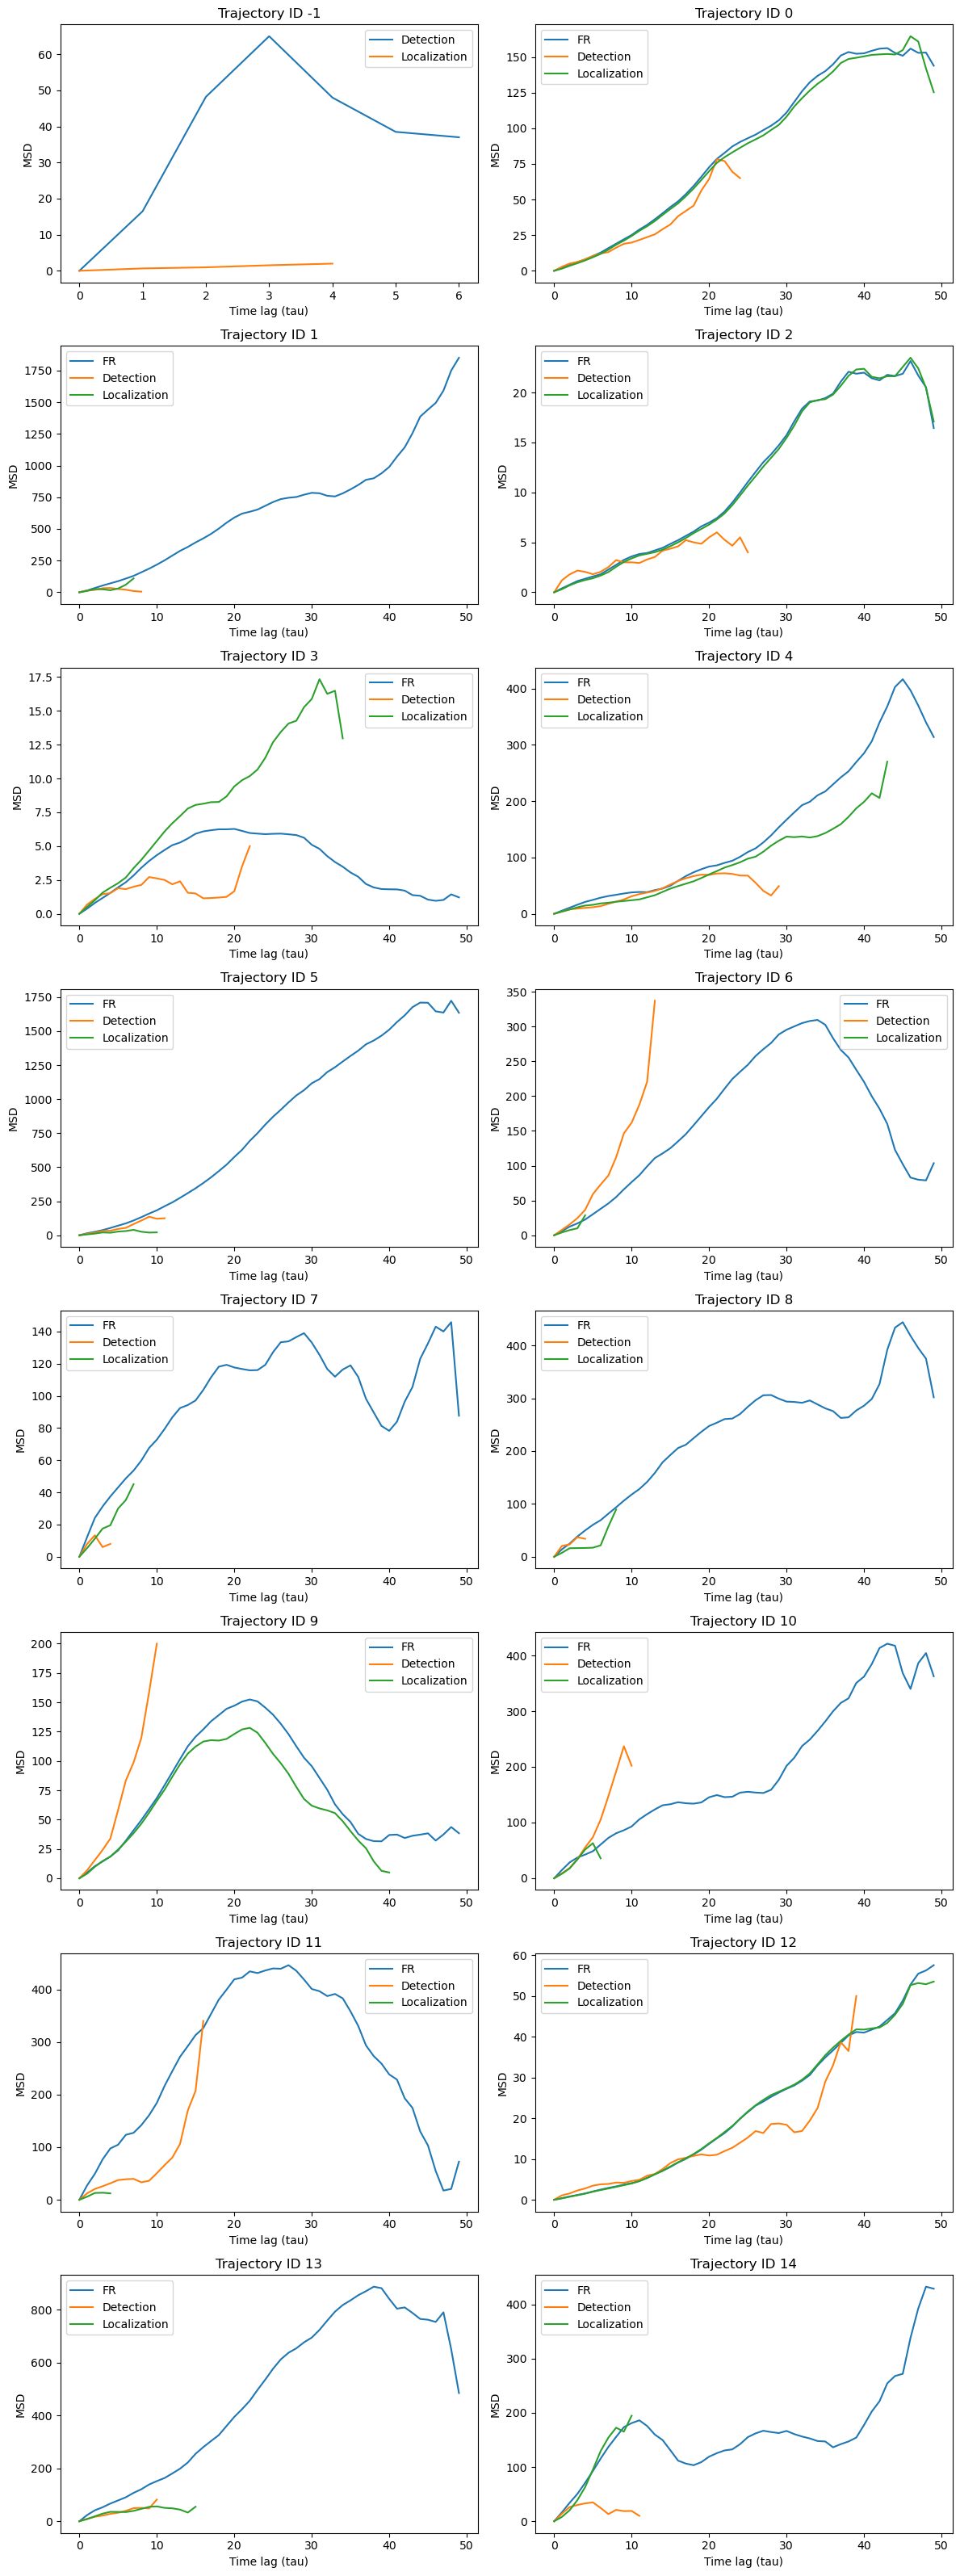

In [69]:
plotMSD_multi(traj_list[-3:], labels)